# ADHD Classification with Dual-View Attention MIL

Each patient has many two-second EEG epochs. This model processes the Full and Simple versions of each epoch, learns which epochs are most informative, and produces one prediction for the patient.

## 1. Setup

We import the required libraries, set random seeds, and select GPU when it is available.

In [1]:
import copy
import pickle
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 2. Load the preprocessed data

The notebook finds the two pickle files attached through Kaggle Input and loads them.

In [2]:
full_files = list(Path("/kaggle/input").rglob("eeg_dataset_full_zscore.pkl"))
simple_files = list(Path("/kaggle/input").rglob("eeg_dataset_simple_zscore.pkl"))

assert len(full_files) == 1, f"Full dataset not found or duplicated: {full_files}"
assert len(simple_files) == 1, f"Simple dataset not found or duplicated: {simple_files}"

with open(full_files[0], "rb") as file:
    full_data = pickle.load(file)

with open(simple_files[0], "rb") as file:
    simple_data = pickle.load(file)

print("Full epochs:", full_data["epochs"].shape)
print("Simple epochs:", simple_data["epochs"].shape)

Full epochs: (16749, 15, 256)
Simple epochs: (16749, 15, 256)


## 3. Check alignment and split patients

The same epoch must correspond to the same patient in both datasets. Patients are then divided into training, validation, and test groups.

In [3]:
assert full_data["epochs"].shape == simple_data["epochs"].shape
assert np.array_equal(full_data["labels"], simple_data["labels"])
assert np.array_equal(full_data["patient_ids"], simple_data["patient_ids"])

full_epochs = full_data["epochs"].astype(np.float32, copy=False)
simple_epochs = simple_data["epochs"].astype(np.float32, copy=False)
epoch_labels = full_data["labels"].astype(np.int64, copy=False)
epoch_patient_ids = full_data["patient_ids"].astype(str)

patient_table = (
    pd.DataFrame({"patient_id": epoch_patient_ids, "label": epoch_labels})
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)

trainval_ids, test_ids = train_test_split(
    patient_table["patient_id"], test_size=0.20,
    stratify=patient_table["label"], random_state=SEED
)
trainval_table = patient_table[patient_table["patient_id"].isin(trainval_ids)]

train_ids, val_ids = train_test_split(
    trainval_table["patient_id"], test_size=0.20,
    stratify=trainval_table["label"], random_state=SEED
)

train_ids = train_ids.to_numpy()
val_ids = val_ids.to_numpy()
test_ids = test_ids.to_numpy()

print(f"Train patients: {len(train_ids)}")
print(f"Validation patients: {len(val_ids)}")
print(f"Test patients: {len(test_ids)}")

Train patients: 76
Validation patients: 20
Test patients: 25


## 4. Create patient bags

A bag contains several epochs belonging to one patient. During training we sample 64 epochs; during evaluation we use all available epochs.

In [4]:
class PatientBagDataset(Dataset):
    def __init__(self, patient_ids, training=False, bag_size=64):
        self.patient_ids = np.asarray(patient_ids).astype(str)
        self.training = training
        self.bag_size = bag_size
        self.patient_indices = {
            pid: np.where(epoch_patient_ids == pid)[0]
            for pid in self.patient_ids
        }

    def __len__(self):
        return len(self.patient_ids)

    def __getitem__(self, index):
        pid = self.patient_ids[index]
        indices = self.patient_indices[pid]

        if self.training:
            replace = len(indices) < self.bag_size
            indices = np.random.choice(indices, self.bag_size, replace=replace)

        full_bag = torch.from_numpy(full_epochs[indices])
        simple_bag = torch.from_numpy(simple_epochs[indices])
        label = torch.tensor(epoch_labels[indices[0]], dtype=torch.float32)

        return full_bag, simple_bag, label, pid


train_dataset = PatientBagDataset(train_ids, training=True, bag_size=64)
val_dataset = PatientBagDataset(val_ids, training=False)
test_dataset = PatientBagDataset(test_ids, training=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

sample_full, sample_simple, sample_label, sample_pid = train_dataset[0]
print("One training bag:", sample_full.shape)
print("Patient:", sample_pid, "Label:", int(sample_label.item()))

One training bag: torch.Size([64, 15, 256])
Patient: v42p Label: 0


## 5. Build the model

Two small CNNs summarize each Full and Simple epoch. A gate combines the two summaries, and attention learns the importance of every epoch.

In [5]:
class EpochEncoder(nn.Module):
    def __init__(self, n_channels, embedding_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=11, padding=5),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, embedding_dim, kernel_size=7, padding=3),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


class DualViewAttentionMIL(nn.Module):
    def __init__(self, n_channels, embedding_dim=64, attention_dim=32, dropout=0.4):
        super().__init__()
        self.full_encoder = EpochEncoder(n_channels, embedding_dim)
        self.simple_encoder = EpochEncoder(n_channels, embedding_dim)

        self.gate = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.Sigmoid(),
        )
        self.attention_v = nn.Linear(embedding_dim, attention_dim)
        self.attention_u = nn.Linear(embedding_dim, attention_dim)
        self.attention_w = nn.Linear(attention_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embedding_dim, 1),
        )

    def forward(self, full_x, simple_x):
        batch_size, n_epochs, n_channels, n_times = full_x.shape

        full_h = self.full_encoder(
            full_x.reshape(batch_size * n_epochs, n_channels, n_times)
        ).reshape(batch_size, n_epochs, -1)

        simple_h = self.simple_encoder(
            simple_x.reshape(batch_size * n_epochs, n_channels, n_times)
        ).reshape(batch_size, n_epochs, -1)

        pair = torch.cat([full_h, simple_h], dim=-1)
        gate = self.gate(pair)
        fused_h = gate * full_h + (1.0 - gate) * simple_h

        attention_features = (
            torch.tanh(self.attention_v(fused_h))
            * torch.sigmoid(self.attention_u(fused_h))
        )
        attention_scores = self.attention_w(attention_features).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1)

        patient_embedding = torch.sum(
            attention_weights.unsqueeze(-1) * fused_h, dim=1
        )
        logits = self.classifier(patient_embedding).squeeze(-1)

        return logits, attention_weights, gate


N_CHANNELS = full_epochs.shape[1]
model = DualViewAttentionMIL(N_CHANNELS).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

DualViewAttentionMIL(
  (full_encoder): EpochEncoder(
    (network): Sequential(
      (0): Conv1d(15, 32, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(11,), stride=(1,), padding=(5,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (9): GELU(approximate='none')
      (10): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (simple_encoder): EpochEncoder(
    (network): Sequential(
      (0): Conv1d(15, 32, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, af

## 6. Evaluation functions

These functions calculate patient-level probabilities and classification metrics.

In [6]:
def classification_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "mcc": matthews_corrcoef(y_true, predictions),
    }


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probabilities, all_patient_ids = [], [], []

    for full_bag, simple_bag, labels, patient_ids in loader:
        full_bag = full_bag.to(DEVICE)
        simple_bag = simple_bag.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, _ = model(full_bag, simple_bag)
        loss = criterion(logits, labels)
        probabilities = torch.sigmoid(logits)

        total_loss += loss.item() * len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_patient_ids.extend(list(patient_ids))

    y_true = np.asarray(all_labels, dtype=int)
    probabilities = np.asarray(all_probabilities)
    metrics = classification_metrics(y_true, probabilities)

    return total_loss / len(y_true), metrics, y_true, probabilities, all_patient_ids

## 7. Train the model

The model is trained on patient bags. Validation ROC-AUC is used for early stopping.

In [7]:
patient_label_map = dict(zip(patient_table["patient_id"], patient_table["label"]))
train_patient_labels = np.array([patient_label_map[pid] for pid in train_ids])
n_control = np.sum(train_patient_labels == 0)
n_adhd = np.sum(train_patient_labels == 1)
positive_weight = torch.tensor([n_control / max(n_adhd, 1)], device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 7
best_val_auc = -np.inf
best_state = None
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for full_bag, simple_bag, labels, _ in train_loader:
        full_bag = full_bag.to(DEVICE)
        simple_bag = simple_bag.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _, _ = model(full_bag, simple_bag)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * len(labels)

    train_loss = running_loss / len(train_dataset)
    val_loss, val_metrics, _, _, _ = evaluate_loader(model, val_loader, criterion)
    val_auc = val_metrics["roc_auc"]
    scheduler.step(val_auc)

    history.append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_loss, "val_auc": val_auc,
        "val_accuracy": val_metrics["accuracy"]
    })

    print(
        f"Epoch {epoch:02d} | train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | val AUC {val_auc:.3f} | "
        f"val accuracy {val_metrics['accuracy']:.3f}"
    )

    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping.")
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print(f"Best validation ROC-AUC: {best_val_auc:.3f}")

Epoch 01 | train loss 0.7291 | val loss 0.6791 | val AUC 0.760 | val accuracy 0.500
Epoch 02 | train loss 0.6600 | val loss 0.5968 | val AUC 0.790 | val accuracy 0.750
Epoch 03 | train loss 0.5788 | val loss 0.4944 | val AUC 0.860 | val accuracy 0.750
Epoch 04 | train loss 0.5624 | val loss 0.5666 | val AUC 0.860 | val accuracy 0.700
Epoch 05 | train loss 0.4927 | val loss 0.4759 | val AUC 0.870 | val accuracy 0.750
Epoch 06 | train loss 0.4517 | val loss 0.4040 | val AUC 0.910 | val accuracy 0.800
Epoch 07 | train loss 0.4525 | val loss 0.4064 | val AUC 0.930 | val accuracy 0.750
Epoch 08 | train loss 0.3208 | val loss 0.4982 | val AUC 0.900 | val accuracy 0.750
Epoch 09 | train loss 0.3932 | val loss 0.4820 | val AUC 0.890 | val accuracy 0.750
Epoch 10 | train loss 0.3282 | val loss 0.4204 | val AUC 0.900 | val accuracy 0.750
Epoch 11 | train loss 0.2786 | val loss 0.4061 | val AUC 0.920 | val accuracy 0.800
Epoch 12 | train loss 0.1591 | val loss 0.4617 | val AUC 0.920 | val accurac

### Training behaviour

The training loss decreased from **0.729** to **0.098**, showing that the model successfully learned patterns from the training patients. The validation ROC-AUC reached its highest value of **0.930 at epoch 7**.

After epoch 7, the training loss continued decreasing, while the validation loss generally increased and the validation AUC did not improve. This suggests the beginning of overfitting. Early stopping therefore ended training after epoch 14 and restored the model parameters from the epoch with the best validation AUC.

Small fluctuations are expected because each training iteration randomly samples 64 epochs from each patient.

## 8. Evaluate unseen test patients

The final model is evaluated once on patients that were not used during training or validation.

,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,mcc
Dual-View Attention MIL,0.72,0.724,0.8,0.615,0.833,0.696,0.737,0.458


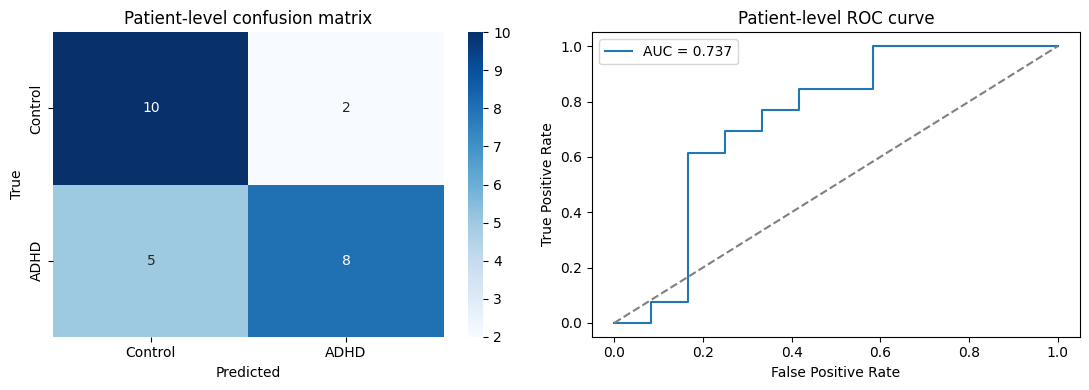

In [8]:
test_loss, test_metrics, y_test, test_probabilities, test_patient_ids = evaluate_loader(
    model, test_loader, criterion
)
test_predictions = (test_probabilities >= 0.5).astype(int)

metrics_df = pd.DataFrame([test_metrics], index=["Dual-View Attention MIL"])
display(metrics_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test, test_predictions, labels=[0, 1])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Control", "ADHD"], yticklabels=["Control", "ADHD"]
)
axes[0].set_title("Patient-level confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

fpr, tpr, _ = roc_curve(y_test, test_probabilities)
axes[1].plot(fpr, tpr, label=f"AUC = {test_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Patient-level ROC curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

### Patient-level test performance

The model was evaluated on **25 completely unseen patients** and achieved:

- **Accuracy: 0.720** — 18 of 25 patients were classified correctly.
- **Balanced accuracy: 0.724** — performance was reasonably balanced across both classes.
- **Precision: 0.800** — 80% of patients predicted as ADHD were actually ADHD.
- **Recall/Sensitivity: 0.615** — the model detected 8 of the 13 ADHD patients.
- **Specificity: 0.833** — the model correctly identified 10 of the 12 Control patients.
- **F1-score: 0.696** — the combined balance between ADHD precision and recall.
- **MCC: 0.458** — a moderate overall relationship between predictions and true diagnoses.
- **ROC-AUC: 0.737** — the model discriminated ADHD from Control better than random classification.  

### Confusion matrix and ROC curve

The confusion matrix shows that the model correctly classified:

- **10 Control patients** as Control.
- **8 ADHD patients** as ADHD.

It incorrectly classified:

- **2 Control patients** as ADHD, called false positives.
- **5 ADHD patients** as Control, called false negatives.

The model therefore recognized Control patients more successfully than ADHD patients, which is also reflected by its higher specificity than recall.

The ROC-AUC of **0.737** indicates useful but not perfect separation between the two groups. The decrease from the best validation AUC of 0.930 to the test AUC of 0.737 shows that performance on unseen patients is more difficult. Some variation is also expected because the validation and test sets contain only 20 and 25 patients.

## 9. Inspect attention

Attention weights show which epochs had the largest influence on one patient's prediction.

Patient: v57p
True label: Control
ADHD probability: 0.489
Average Full-view gate: 0.581
Top five attended epoch indices: [ 48 104  53  56  68]


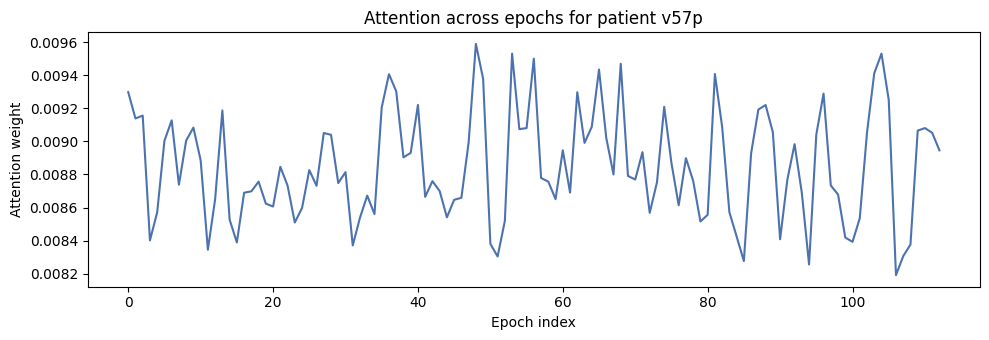

In [9]:
chosen_index = 0
full_bag, simple_bag, label, patient_id = test_dataset[chosen_index]

model.eval()
with torch.no_grad():
    logits, attention_weights, gates = model(
        full_bag.unsqueeze(0).to(DEVICE),
        simple_bag.unsqueeze(0).to(DEVICE),
    )

probability = torch.sigmoid(logits).item()
weights = attention_weights.squeeze(0).cpu().numpy()
mean_full_gate = gates.mean().item()

print("Patient:", patient_id)
print("True label:", "ADHD" if label.item() == 1 else "Control")
print(f"ADHD probability: {probability:.3f}")
print(f"Average Full-view gate: {mean_full_gate:.3f}")
print("Top five attended epoch indices:", np.argsort(weights)[-5:][::-1])

plt.figure(figsize=(10, 3.5))
plt.plot(weights, color="#4C72B0")
plt.xlabel("Epoch index")
plt.ylabel("Attention weight")
plt.title(f"Attention across epochs for patient {patient_id}")
plt.tight_layout()
plt.show()

### Attention interpretation for patient v57p

Patient **v57p** is a Control patient. The model produced an ADHD probability of **0.489**. Because this value is slightly below the 0.5 decision threshold, the patient was correctly classified as Control. However, the probability is very close to the threshold, indicating that the model was uncertain about this patient.

The average Full-view gate was **0.581**, showing a modest preference for information from the Full preprocessing pipeline while still using information from the Simple pipeline.

The most attended epochs were **48, 104, 53, 56 and 68**. These epochs had the greatest influence on the patient representation. However, the attention weights are relatively similar across the recording, suggesting that the model used information from many epochs rather than depending strongly on only one or two segments.

## 10. Save results

The trained model, patient predictions, metrics, and training history are saved to Kaggle Working.

In [10]:
output_dir = Path("/kaggle/working")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_channels": N_CHANNELS,
        "channel_names": full_data["channel_names"],
        "seed": SEED,
    },
    output_dir / "dual_view_attention_mil.pt",
)

predictions_df = pd.DataFrame({
    "patient_id": test_patient_ids,
    "y_true": y_test,
    "adhd_probability": test_probabilities,
    "y_pred": test_predictions,
})

predictions_df.to_csv(output_dir / "dual_view_patient_predictions.csv", index=False)
metrics_df.to_csv(output_dir / "dual_view_test_metrics.csv")
history_df.to_csv(output_dir / "dual_view_training_history.csv", index=False)

print("Saved model and result files to /kaggle/working")

Saved model and result files to /kaggle/working


### Overall interpretation

The Dual-View Attention MIL model successfully learned to make diagnoses directly at the patient level using both preprocessing views. It achieved 72% accuracy and 0.737 ROC-AUC on unseen patients.

The results demonstrate that patient-level attention is a feasible alternative to independently classifying EEG epochs. The model was particularly effective at recognizing Control patients, although its lower ADHD recall shows that some ADHD patients were still missed. Further evaluation with cross-validation would help determine how stable these results are across different patient splits.